# TABVERSE — SUC Evaluation Analysis
Structural Understanding Competencies (SUC) — per-task accuracy breakdown.

| Section | Focus |
|---------|-------|
| **1. Primary Tables** | Per-pipeline model × task accuracy (%) |
| **2. Task Difficulty** | Global ranking: easiest → hardest tasks |
| **3. Format Sensitivity** | How much HTML / LaTeX / Markdown affect per task |
| **4. Pipeline Comparison** | VLM vs VLM-TEXT vs LLM side-by-side |


In [1]:
import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

matplotlib.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_theme(style="whitegrid")


In [2]:
def _find_root():
    cwd = Path.cwd()
    for _ in range(6):
        if (cwd / "results").exists() and (cwd / "src").exists():
            return cwd
        cwd = cwd.parent
    raise FileNotFoundError("TABVERSE root not found — run from inside the repo")

ROOT = _find_root()
FINAL_CSV_DIR = ROOT / "results" / "scores" / "suc"
print(f"ROOT         : {ROOT}")
print(f"CSV dir      : {FINAL_CSV_DIR}")


ROOT         : /home/momina.ahsan/TABVERSE
CSV dir      : /home/momina.ahsan/TABVERSE/results/scores/suc


In [3]:
suc_csv = FINAL_CSV_DIR / "suc.csv"
if not suc_csv.exists():
    raise FileNotFoundError(f"{suc_csv} not found — run eval_suc.py first.")

df_all = pd.read_csv(suc_csv)

# Split into per-task rows and OVERALL rows
df      = df_all[df_all["task"] != "OVERALL"].copy()
df_ov   = df_all[df_all["task"] == "OVERALL"].copy()

TASK_ABBREV = {
    "table_partition":   "T.P.",
    "table_first_cell":  "F.C.",
    "table_last_cell":   "L.C.",
    "size_detection":    "S.D.",
    "number_of_rows":    "#Rows",
    "number_of_columns": "#Cols",
    "cell_lookup":       "C.Lu.",
    "reverse_lookup":    "R.Lu.",
    "column_retrieval":  "Co.Rt.",
    "row_retrieval":     "Ro.Rt.",
}
TASK_ORDER   = list(TASK_ABBREV.keys())
ABBREV_ORDER = list(TASK_ABBREV.values())
PIPELINE_ORDER = ["VLM", "VLM-TEXT", "LLM"]

print(f"Rows (per-task) : {len(df)}")
print(f"Rows (OVERALL)  : {len(df_ov)}")
print(f"Pipelines found : {sorted(df['pipeline'].unique())}")
print(f"Models found    : {sorted(df['model'].unique())}")


Rows (per-task) : 1790
Rows (OVERALL)  : 179
Pipelines found : ['LLM', 'VLM', 'VLM-TEXT']
Models found    : ['InternVL3.5-14B', 'InternVL3.5-30B-A3B', 'Qwen2.5-7B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-VL-30B-A3B-Instruct', 'Qwen3-VL-8B-Instruct', 'SmolVLM2-2.2B-Instruct', 'TAMA-QWen3', 'TableGPT2-7B', 'gemini-3-flash-preview', 'gemma_3-12B-IT', 'gemma_3-27B-IT', 'gpt-5.2', 'llava_1.6-vicuna-13B', 'llava_1.6-vicuna-7B', 'ministral_3-14B-Instruct', 'table-llava-v1.5-7b-hf']


---
## 1. Primary Results Tables

One table per pipeline — rows = model × format, columns = SUC tasks (%).  
Source: `results/scores/suc/suc_{pipeline}.csv` (generated by `eval_suc.py`).


In [4]:
PIPELINE_CSVS = {
    "VLM":      "suc_vlm.csv",
    "VLM-TEXT": "suc_vlm_text.csv",
    "LLM":      "suc_llm.csv",
}

for label, csv_name in PIPELINE_CSVS.items():
    p = FINAL_CSV_DIR / csv_name
    if not p.exists():
        print(f"[SKIP] {csv_name} not found — run eval_suc.py first.")
        continue
    wide = pd.read_csv(p)
    num_cols = [c for c in wide.columns if c not in ("model", "format")]
    print(f"\n{'─' * 70}")
    print(f"  {label} Pipeline")
    print(f"{'─' * 70}")
    display(
        wide.style
            .format("{:.1f}", subset=num_cols, na_rep="-")
            .background_gradient(axis=None, cmap="RdYlGn", subset=num_cols,
                                 vmin=0, vmax=100)
            .set_caption(f"{label} — SUC Task Accuracy (%)")
            .set_table_styles([{"selector": "caption",
                                "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    )



──────────────────────────────────────────────────────────────────────
  VLM Pipeline
──────────────────────────────────────────────────────────────────────


,model,format,T.P.,F.C.,L.C.,S.D.,#Rows,#Cols,C.Lu.,R.Lu.,Co.Rt.,Ro.Rt.,OVERALL
0,InternVL3.5-14B,html,35.3,86.8,68.4,22.3,55.3,89.8,15.6,15.9,84.6,4.1,47.8
1,InternVL3.5-14B,markdown,31.6,83.0,65.3,32.3,51.0,86.6,20.3,23.5,88.9,5.4,48.8
2,InternVL3.5-14B,latex,38.0,88.6,71.9,16.4,28.6,83.1,18.9,22.7,90.1,6.4,46.5
3,InternVL3.5-30B-A3B,html,0.0,88.9,79.0,8.7,39.9,88.6,17.8,9.2,53.7,2.2,38.8
4,InternVL3.5-30B-A3B,markdown,0.0,84.9,76.5,25.1,56.1,85.5,24.5,13.0,64.9,4.5,43.5
5,InternVL3.5-30B-A3B,latex,0.0,89.2,80.6,12.6,44.5,83.5,21.5,15.9,69.8,4.0,42.1
6,Qwen3-VL-30B-A3B-Instruct,html,50.2,92.5,85.2,32.9,44.2,91.9,21.1,24.3,71.1,0.2,51.4
7,Qwen3-VL-30B-A3B-Instruct,markdown,40.1,87.9,78.7,32.0,41.7,87.4,21.6,25.1,88.9,1.1,50.4
8,Qwen3-VL-30B-A3B-Instruct,latex,45.6,92.7,82.2,34.2,40.2,87.4,22.3,27.3,83.8,4.0,52.0
9,Qwen3-VL-8B-Instruct,html,23.8,93.3,80.9,8.1,25.6,89.3,27.0,26.6,90.1,1.0,46.6



──────────────────────────────────────────────────────────────────────
  VLM-TEXT Pipeline
──────────────────────────────────────────────────────────────────────


,model,format,T.P.,F.C.,L.C.,S.D.,#Rows,#Cols,C.Lu.,R.Lu.,Co.Rt.,Ro.Rt.,OVERALL
0,InternVL3.5-14B,html,8.4,95.5,78.7,8.4,50.6,98.4,50.9,44.2,95.2,8.6,53.9
1,InternVL3.5-14B,markdown,1.4,76.3,71.4,14.5,65.7,85.9,43.6,33.2,83.9,3.3,47.9
2,InternVL3.5-14B,latex,11.1,94.1,76.0,11.0,44.2,99.4,36.9,22.3,87.1,6.8,48.9
3,InternVL3.5-30B-A3B,html,0.0,91.6,75.5,0.0,11.6,99.5,42.9,31.0,87.0,30.2,46.9
4,InternVL3.5-30B-A3B,markdown,0.0,64.4,75.4,0.0,15.7,97.1,32.4,28.5,86.2,21.5,42.1
5,InternVL3.5-30B-A3B,latex,0.0,85.1,75.8,0.0,9.1,99.4,28.8,21.0,86.8,21.9,42.8
6,Qwen3-VL-30B-A3B-Instruct,html,49.9,94.6,76.8,68.5,73.4,96.7,40.5,37.5,89.7,14.3,64.2
7,Qwen3-VL-30B-A3B-Instruct,markdown,26.4,87.8,64.9,62.3,84.6,71.7,29.6,20.8,72.2,5.9,52.6
8,Qwen3-VL-30B-A3B-Instruct,latex,29.4,95.5,69.6,46.9,64.5,97.5,29.7,19.7,83.0,8.6,54.5
9,Qwen3-VL-8B-Instruct,html,26.9,93.5,80.0,27.8,69.0,98.3,45.3,47.9,84.9,3.2,57.7



──────────────────────────────────────────────────────────────────────
  LLM Pipeline
──────────────────────────────────────────────────────────────────────


,model,format,T.P.,F.C.,L.C.,S.D.,#Rows,#Cols,C.Lu.,R.Lu.,Co.Rt.,Ro.Rt.,OVERALL
0,Qwen2.5-7B-Instruct,html,16.7,95.1,57.7,20.5,52.3,80.0,25.4,14.3,75.4,5.7,44.3
1,Qwen2.5-7B-Instruct,markdown,5.9,55.6,53.7,15.1,62.5,43.7,8.1,9.2,52.6,2.7,30.9
2,Qwen2.5-7B-Instruct,latex,11.1,44.4,54.8,3.3,34.3,99.0,7.3,5.2,61.4,5.4,32.6
3,Qwen3-30B-A3B-Instruct-2507,html,45.0,94.8,68.0,72.2,81.1,89.8,44.7,25.0,82.2,4.8,60.7
4,Qwen3-30B-A3B-Instruct-2507,markdown,23.4,83.5,56.0,57.6,75.5,44.4,28.9,9.2,63.4,1.4,44.3
5,Qwen3-30B-A3B-Instruct-2507,latex,25.6,91.3,60.9,45.5,51.2,85.4,28.3,9.4,66.9,2.2,46.7
6,TAMA-QWen3,html,7.2,48.5,4.9,6.8,15.1,44.2,6.4,9.4,86.0,0.6,22.9
7,TAMA-QWen3,markdown,4.6,38.0,6.0,0.0,3.2,54.2,1.7,3.5,83.6,0.3,19.5
8,TAMA-QWen3,latex,12.1,35.1,15.9,0.0,0.0,51.0,2.1,2.1,59.3,0.2,17.8
9,TableGPT2-7B,html,20.8,94.1,68.4,31.0,49.0,78.7,13.5,12.9,66.8,3.2,43.8


---
## 2. Task Difficulty

Global mean accuracy per task (averaged over all pipelines, models, formats).  
Reveals which SUC competencies are inherently easy vs. hard.


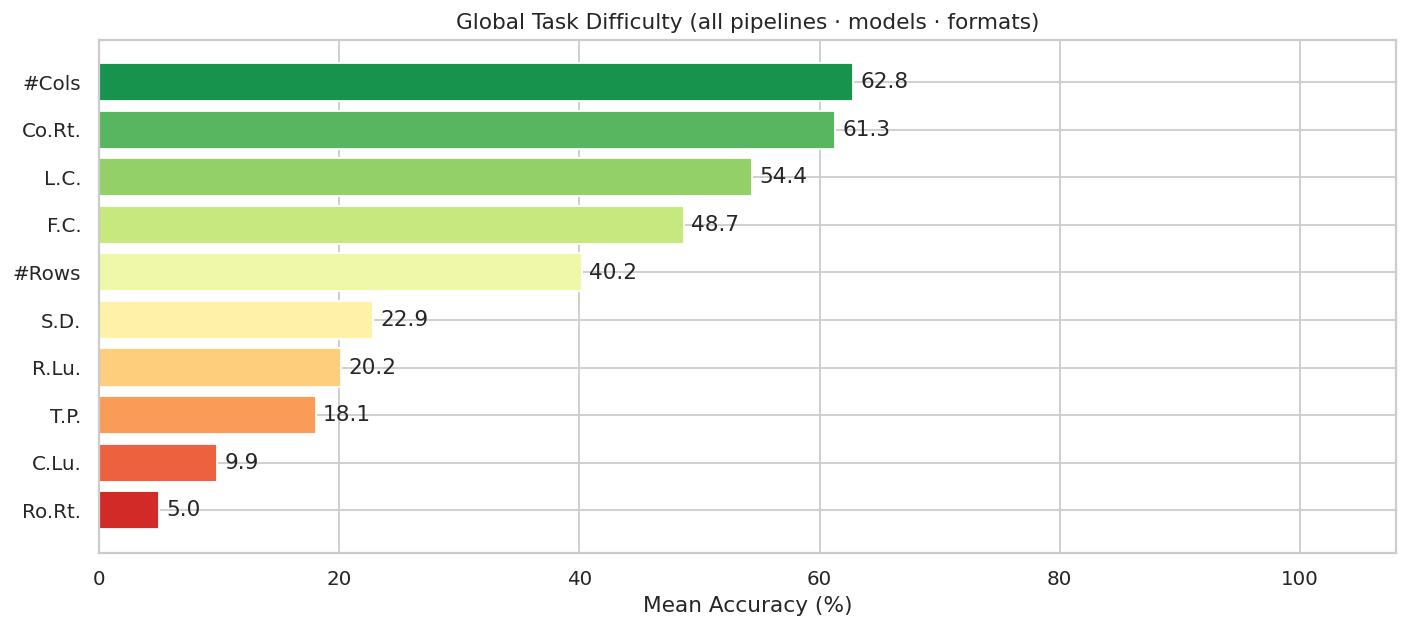

,Short,Task,Avg Acc %
0,#Cols,number_of_columns,62.81
1,Co.Rt.,column_retrieval,61.28
2,L.C.,table_last_cell,54.40
3,F.C.,table_first_cell,48.72
4,#Rows,number_of_rows,40.19
5,S.D.,size_detection,22.86
6,R.Lu.,reverse_lookup,20.16
7,T.P.,table_partition,18.05
8,C.Lu.,cell_lookup,9.88
9,Ro.Rt.,row_retrieval,5.01


In [5]:
task_global = (
    df.groupby("task")["accuracy_pct"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"task": "task_key", "accuracy_pct": "avg_acc"})
)
task_global["abbrev"] = task_global["task_key"].map(TASK_ABBREV)
task_global = task_global.sort_values("avg_acc", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("RdYlGn", len(task_global))
bars = ax.barh(
    task_global["abbrev"][::-1],
    task_global["avg_acc"][::-1],
    color=palette,
)
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_xlabel("Mean Accuracy (%)")
ax.set_xlim(0, 108)
ax.set_title("Global Task Difficulty (all pipelines · models · formats)")
plt.tight_layout()
plt.show()

display(
    task_global[["abbrev", "task_key", "avg_acc"]]
    .rename(columns={"abbrev": "Short", "task_key": "Task", "avg_acc": "Avg Acc %"})
    .reset_index(drop=True)
)


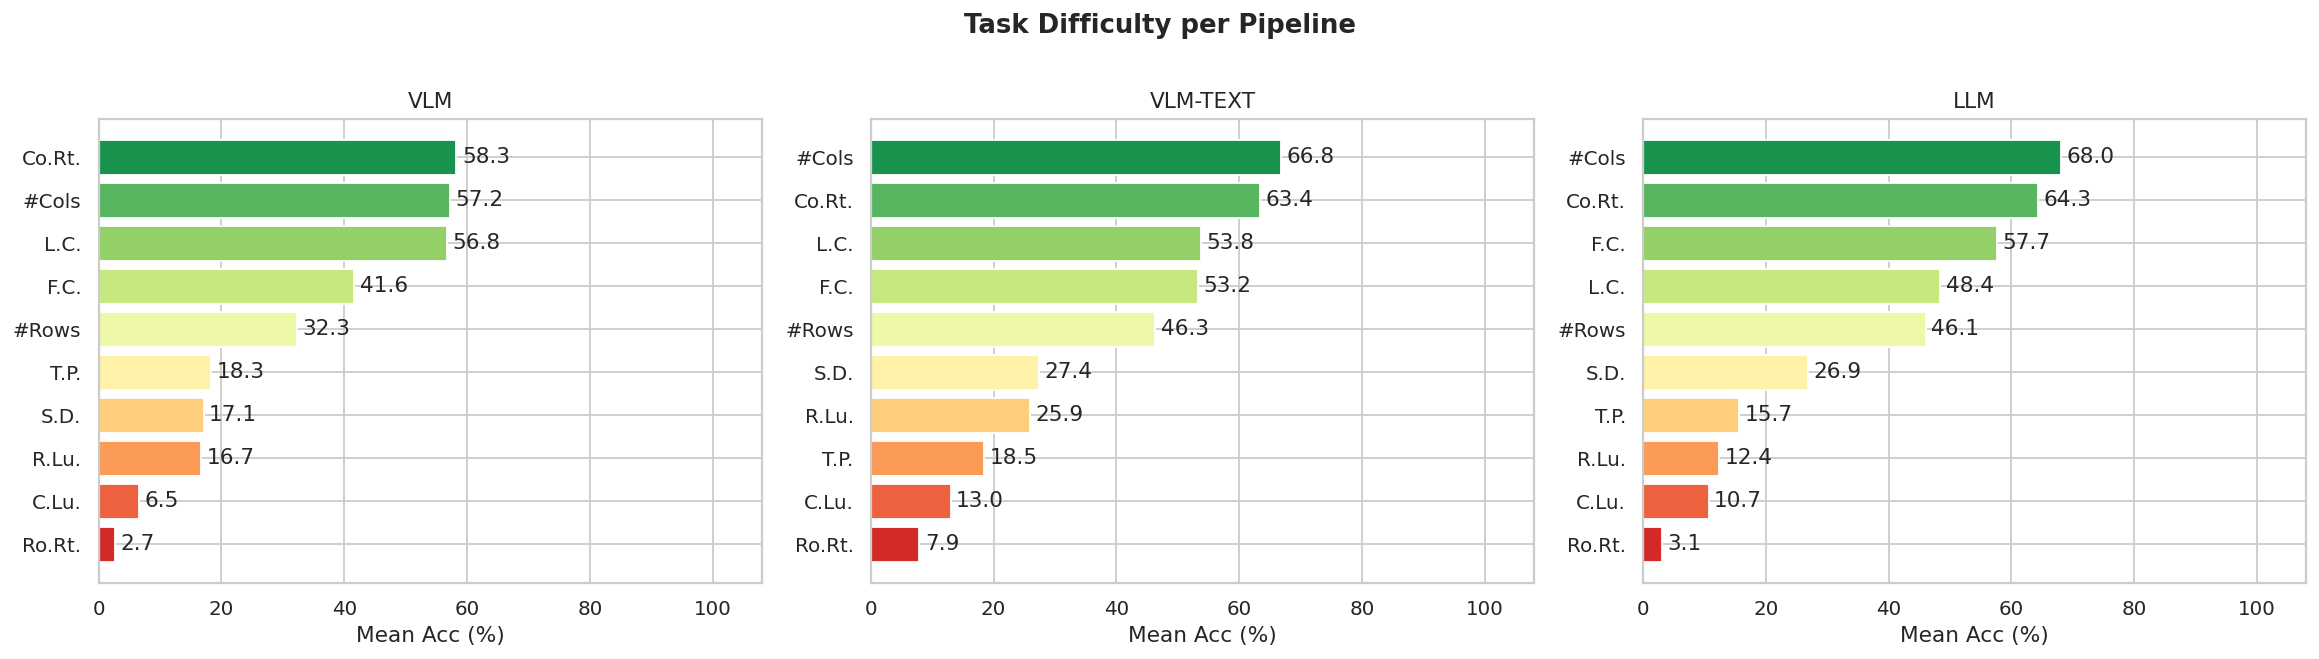

In [6]:
# Per-pipeline task ranking — does task difficulty differ by pipeline?
pipe_task_avg = (
    df.groupby(["pipeline", "task"])["accuracy_pct"]
    .mean().round(2).reset_index()
)
pipe_task_avg["abbrev"] = pipe_task_avg["task"].map(TASK_ABBREV)

pipelines_present = [p for p in PIPELINE_ORDER if p in pipe_task_avg["pipeline"].unique()]
n = len(pipelines_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, pipeline in zip(axes, pipelines_present):
    sub = (
        pipe_task_avg[pipe_task_avg["pipeline"] == pipeline]
        .sort_values("accuracy_pct", ascending=True)
    )
    bars = ax.barh(sub["abbrev"], sub["accuracy_pct"],
                   color=sns.color_palette("RdYlGn", len(sub)))
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlim(0, 108)
    ax.set_title(pipeline)
    ax.set_xlabel("Mean Acc (%)")

fig.suptitle("Task Difficulty per Pipeline", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Format Sensitivity

Standard deviation of accuracy across HTML / LaTeX / Markdown **per task**.  
High std → task result is highly format-dependent; low std → robust to representation.


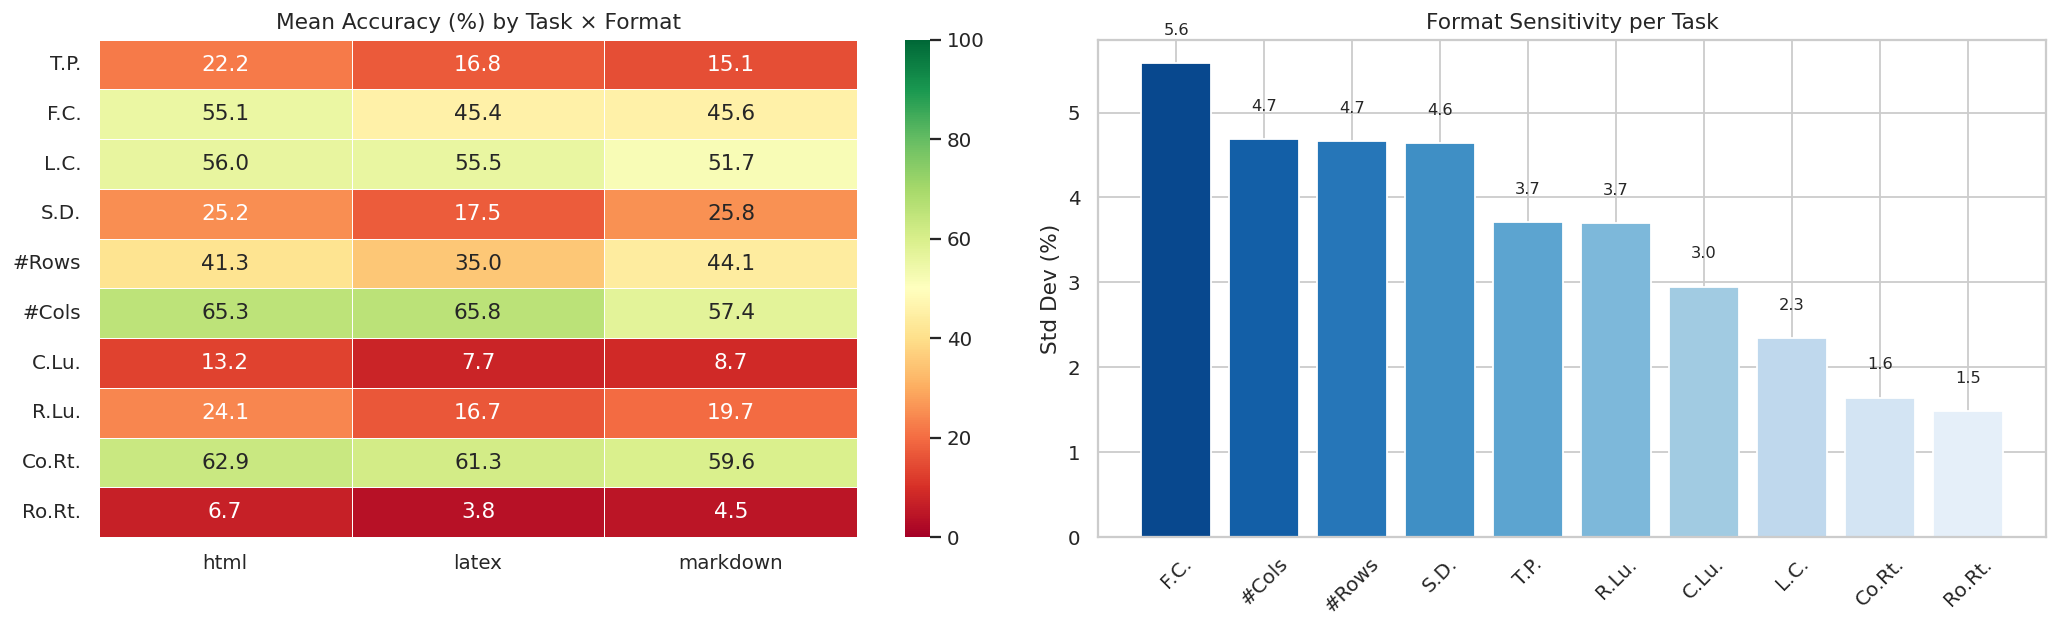


Format sensitivity table:


format,html,latex,markdown,std
T.P.,22.22,16.80,15.12,3.71
F.C.,55.15,45.38,45.58,5.58
L.C.,55.97,55.54,51.72,2.34
S.D.,25.24,17.48,25.76,4.64
#Rows,41.34,35.03,44.12,4.66
#Cols,65.30,65.76,57.41,4.69
C.Lu.,13.22,7.70,8.68,2.95
R.Lu.,24.05,16.70,19.67,3.70
Co.Rt.,62.90,61.32,59.63,1.64
Ro.Rt.,6.67,3.83,4.50,1.48


In [7]:
fmt_avg = (
    df.groupby(["task", "format"])["accuracy_pct"]
    .mean().round(2).reset_index()
)
fmt_pivot = (
    fmt_avg.pivot(index="task", columns="format", values="accuracy_pct")
    .reindex(TASK_ORDER)
)
fmt_col_order = [c for c in ["html", "latex", "markdown"] if c in fmt_pivot.columns]
fmt_pivot = fmt_pivot[fmt_col_order]
fmt_pivot["std"] = fmt_pivot[fmt_col_order].std(axis=1).round(2)
fmt_pivot.index = [TASK_ABBREV.get(t, t) for t in fmt_pivot.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: heatmap
sns.heatmap(
    fmt_pivot[fmt_col_order], annot=True, fmt=".1f",
    cmap="RdYlGn", vmin=0, vmax=100,
    linewidths=0.4, ax=axes[0],
)
axes[0].set_title("Mean Accuracy (%) by Task × Format")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Right: std dev bar
std_sorted = fmt_pivot["std"].sort_values(ascending=False)
axes[1].bar(std_sorted.index, std_sorted.values,
            color=sns.color_palette("Blues_r", len(std_sorted)))
axes[1].set_ylabel("Std Dev (%)")
axes[1].set_title("Format Sensitivity per Task")
axes[1].tick_params(axis="x", rotation=45)
for bar, val in zip(axes[1].patches, std_sorted.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("\nFormat sensitivity table:")
display(fmt_pivot.round(2))


---
## 4. Pipeline Comparison

Mean accuracy per task for each pipeline (VLM / VLM-TEXT / LLM).  
Shows whether text-only or image-based pipelines handle specific tasks differently.


pipeline,VLM,VLM-TEXT,LLM
abbrev,,,
T.P.,18.32,18.49,15.66
F.C.,41.60,53.20,57.67
L.C.,56.76,53.82,48.39
S.D.,17.10,27.43,26.88
#Rows,32.31,46.34,46.08
#Cols,57.22,66.85,68.03
C.Lu.,6.52,13.01,10.69
R.Lu.,16.74,25.87,12.38
Co.Rt.,58.27,63.42,64.27


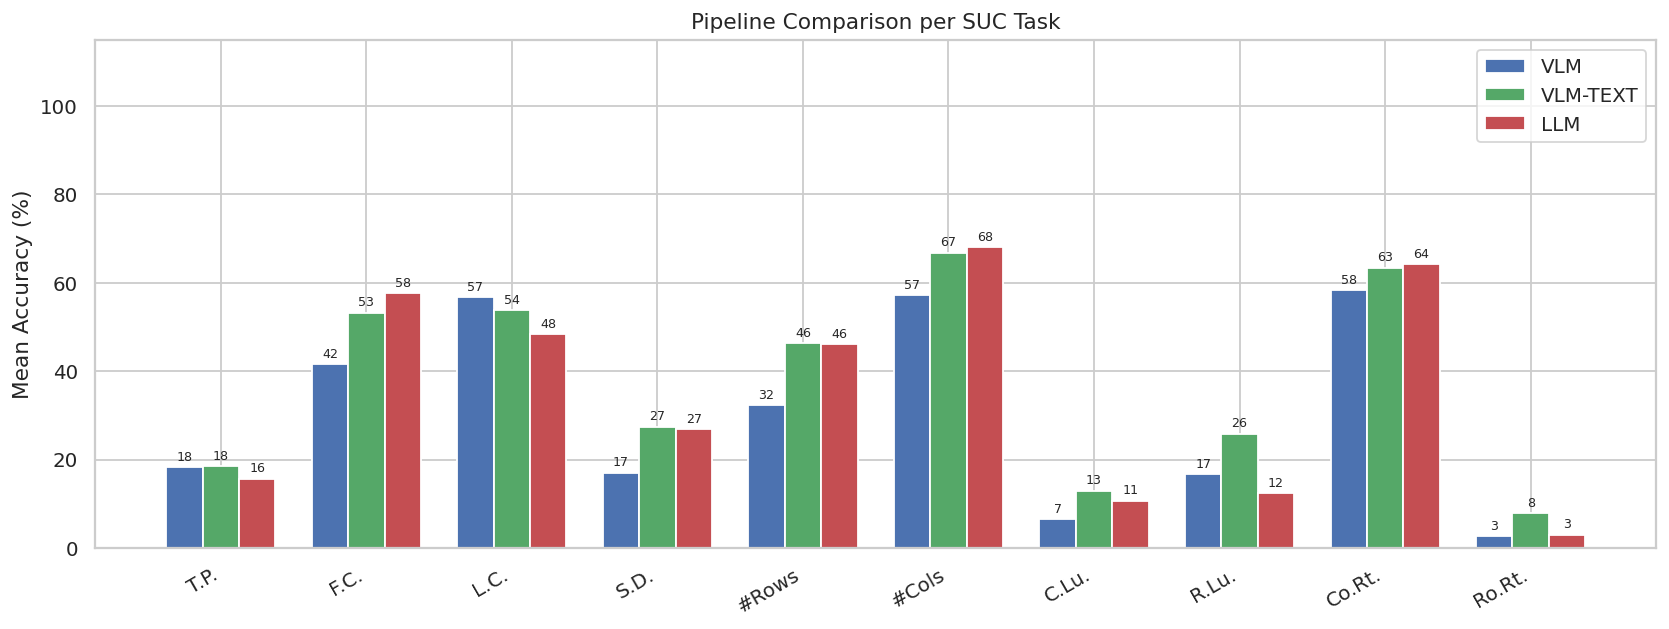

In [8]:
pipe_task_wide = (
    pipe_task_avg.pivot_table(
        index="abbrev", columns="pipeline", values="accuracy_pct"
    )
    .reindex(ABBREV_ORDER)
)
col_order = [c for c in PIPELINE_ORDER if c in pipe_task_wide.columns]
pipe_task_wide = pipe_task_wide[col_order]

display(pipe_task_wide.round(2))

x = range(len(pipe_task_wide))
w = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
fig, ax = plt.subplots(figsize=(13, 5))
for i, col in enumerate(col_order):
    offset = [xi + i * w for xi in x]
    bars = ax.bar(offset, pipe_task_wide[col], width=w, label=col, color=colors[i])
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=7)

ax.set_xticks([xi + w * (len(col_order) - 1) / 2 for xi in x])
ax.set_xticklabels(pipe_task_wide.index, rotation=30, ha="right")
ax.set_ylabel("Mean Accuracy (%)")
ax.set_ylim(0, 115)
ax.set_title("Pipeline Comparison per SUC Task")
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Model Leaderboard

Overall accuracy (avg across all tasks + formats) per model, grouped by pipeline.


,pipeline,model,overall_avg_%
1,LLM,Qwen3-30B-A3B-Instruct-2507,49.87
3,LLM,TableGPT2-7B,39.80
0,LLM,Qwen2.5-7B-Instruct,32.05
2,LLM,TAMA-QWen3,16.52
12,VLM,gpt-5.2,57.17
6,VLM,Qwen3-VL-30B-A3B-Instruct,43.88
4,VLM,InternVL3.5-14B,40.83
9,VLM,gemini-3-flash-preview,40.20
7,VLM,Qwen3-VL-8B-Instruct,38.42
15,VLM,ministral_3-14B-Instruct,36.95


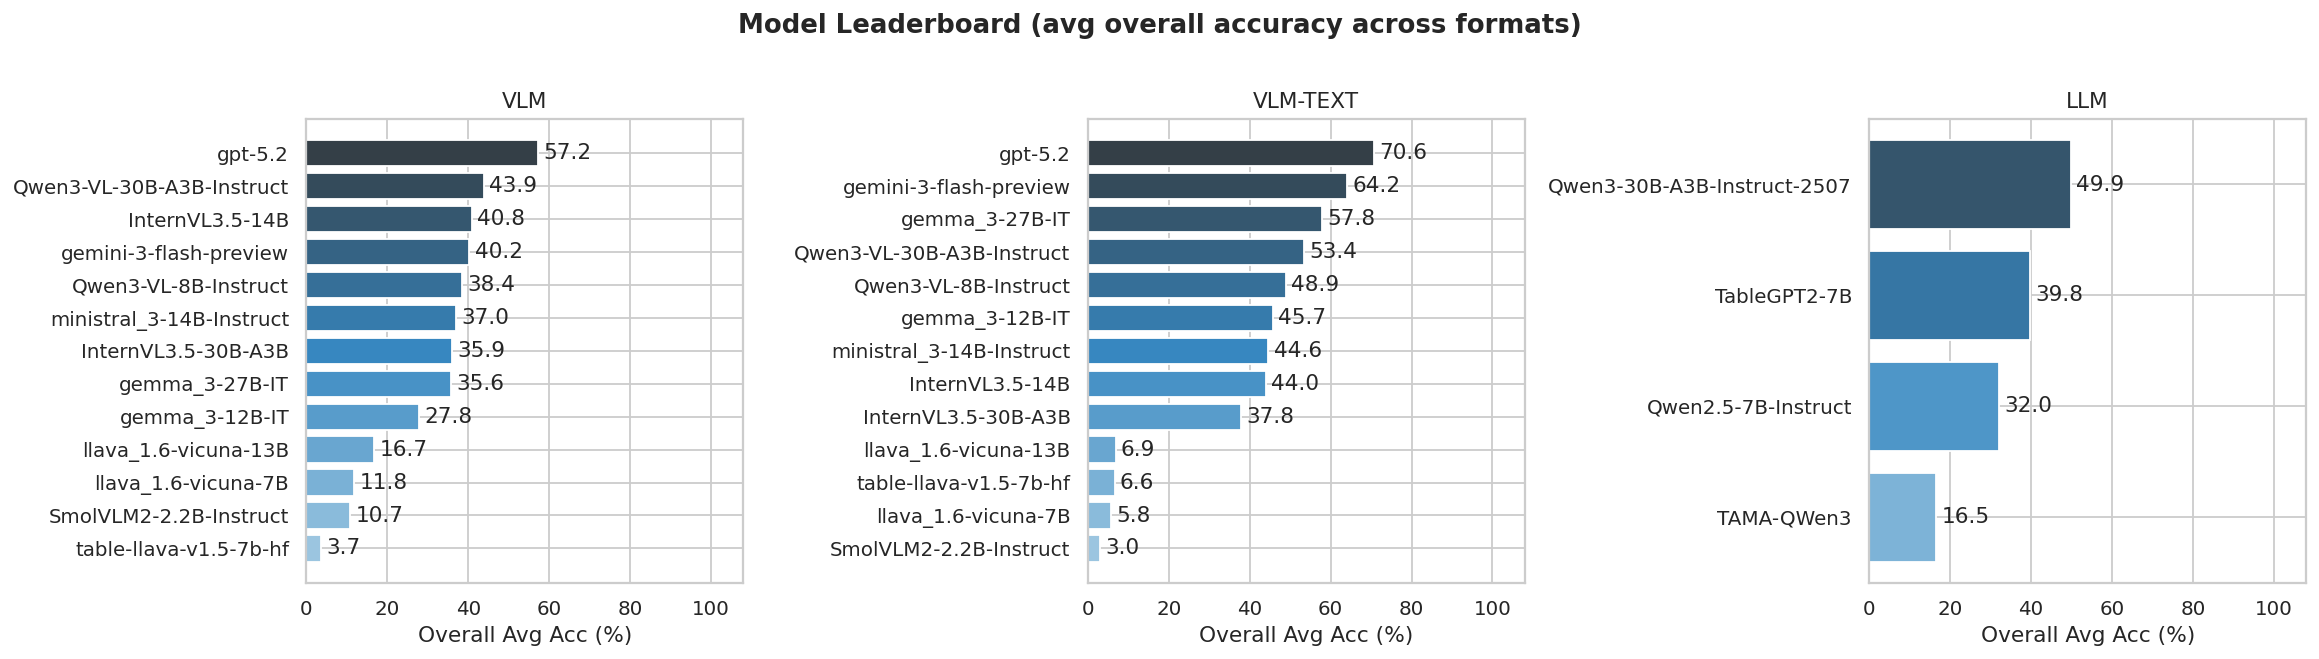

In [9]:
leaderboard = (
    df_ov.groupby(["pipeline", "model"])["accuracy_pct"]
    .mean().round(2).reset_index()
    .sort_values(["pipeline", "accuracy_pct"], ascending=[True, False])
)
display(leaderboard.rename(columns={"accuracy_pct": "overall_avg_%"}))

pipelines_present = [p for p in PIPELINE_ORDER if p in leaderboard["pipeline"].unique()]
n = len(pipelines_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, pipeline in zip(axes, pipelines_present):
    sub = leaderboard[leaderboard["pipeline"] == pipeline].sort_values("accuracy_pct")
    bars = ax.barh(sub["model"], sub["accuracy_pct"],
                   color=sns.color_palette("Blues_d", len(sub)))
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlim(0, 108)
    ax.set_title(pipeline)
    ax.set_xlabel("Overall Avg Acc (%)")

fig.suptitle("Model Leaderboard (avg overall accuracy across formats)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
